# Diagnose DQN reward outliers

This notebook investigates why the DQN learning curve contains extremely negative reward episodes. It is analysis-only: it reads result CSV files and optional TensorBoard logs, but does not modify the environment, reward function, training code, or configuration.

## Load evaluation and TensorBoard data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"
LOG_DIR = PROJECT_ROOT / "logs" / "dqn_ran_slicing_300k"
TB_TAG = "rollout/ep_rew_mean"

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "font.size": 11,
    }
)

def latest_file(pattern, root=RESULTS_DIR):
    matches = sorted(root.glob(pattern), key=lambda path: path.stat().st_mtime, reverse=True)
    if not matches:
        raise FileNotFoundError(f"No files found for {root / pattern}")
    return matches[0]

steps_path = latest_file("dqn_300k_steps_*.csv")
summary_path = latest_file("dqn_300k_summary_*.csv")

steps_df = pd.read_csv(steps_path)
summary_df = pd.read_csv(summary_path)

print(f"Loaded step-level results: {steps_path}")
print(f"Loaded episode summary: {summary_path}")
print(f"Step rows: {len(steps_df)}")
print(f"Episode rows: {len(summary_df)}")

required_columns = [
    "episode", "step", "action", "alpha_A", "n_ambulance", "ambulance_emergency",
    "ambulance_arrival_mbit", "ambulance_capacity_mbps", "ambulance_queue_mbit",
    "ambulance_latency_s", "ambulance_sla_violation", "ordinary_throughput_mbps",
    "prb_utilization", "reward_total",
]
missing = [column for column in required_columns if column not in steps_df.columns]
if missing:
    raise KeyError(f"Missing required step columns: {missing}. Available columns: {list(steps_df.columns)}")

numeric_columns = [
    "reward_total", "alpha_A", "n_ambulance", "ambulance_arrival_mbit",
    "ambulance_capacity_mbps", "ambulance_queue_mbit", "ambulance_latency_s",
    "ambulance_sla_violation", "ordinary_throughput_mbps", "prb_utilization",
]
for column in numeric_columns:
    steps_df[column] = pd.to_numeric(steps_df[column], errors="coerce")

def parse_boolean_series(series):
    if series.dtype == bool:
        return series
    return series.astype(str).str.lower().isin(["true", "1", "yes"])

steps_df["ambulance_emergency_bool"] = parse_boolean_series(steps_df["ambulance_emergency"])
steps_df.head()

Loaded step-level results: D:\Projects\dqn-ran-slicing-oran-iov\results\dqn_300k_steps_20260605_115356.csv
Loaded episode summary: D:\Projects\dqn-ran-slicing-oran-iov\results\dqn_300k_summary_20260605_115356.csv
Step rows: 6000
Episode rows: 30


,episode,step,action,alpha_A,prb_ambulance,prb_ordinary,ambulance_arrival_mbit,ordinary_arrival_mbit,ambulance_capacity_mbps,ordinary_capacity_mbps,...,ambulance_sla_violation,ordinary_throughput_mbps,prb_utilization,reward_total,n_ambulance,n_ordinary_vehicles,n_embb_users,ambulance_emergency,embb_surge_active,ambulance_emergency_bool
0,0,0,2,0.3,30,70,0.0,7.92,0.0,16.456650,...,0,7.92,0.336884,0.9900,0,46,13,False,False,False
1,0,1,2,0.3,30,70,0.0,7.38,0.0,16.596642,...,0,7.38,0.311266,0.9225,0,46,13,False,False,False
2,0,2,2,0.3,30,70,0.0,10.20,0.0,15.519641,...,0,10.20,0.460060,1.0000,0,46,13,False,False,False
3,0,3,2,0.3,30,70,0.0,8.64,0.0,16.819433,...,0,8.64,0.359583,1.0000,0,46,13,False,False,False
4,0,4,2,0.3,30,70,0.0,6.88,0.0,16.743460,...,0,6.88,0.287634,0.8600,0,46,13,False,False,False


In [2]:
def load_tensorboard_scalar(log_dir, tag):
    if not log_dir.exists():
        print(f"TensorBoard log directory not found: {log_dir}")
        return None

    event_files = sorted(log_dir.rglob("events.out.tfevents.*"), key=lambda path: path.stat().st_mtime)
    if not event_files:
        print(f"No TensorBoard event files found under {log_dir}")
        return None

    rows = []
    available_tags = set()
    for event_file in event_files:
        accumulator = EventAccumulator(str(event_file))
        accumulator.Reload()
        scalar_tags = accumulator.Tags().get("scalars", [])
        available_tags.update(scalar_tags)
        if tag not in scalar_tags:
            continue
        for event in accumulator.Scalars(tag):
            rows.append({"step": event.step, "reward": event.value, "event_file": str(event_file)})

    if not rows:
        print(f"TensorBoard scalar tag not found: {tag}")
        print("Available scalar tags:")
        for scalar_tag in sorted(available_tags):
            print(f"- {scalar_tag}")
        return None

    df = pd.DataFrame(rows).sort_values("step").drop_duplicates(subset="step", keep="last")
    return df.reset_index(drop=True)

tb_df = load_tensorboard_scalar(LOG_DIR, TB_TAG)
if tb_df is not None:
    print(f"Loaded TensorBoard points: {len(tb_df)}")
    display(tb_df.head())

Loaded TensorBoard points: 375


,step,reward,event_file
0,800,-220.510513,D:\Projects\dqn-ran-slicing-oran-iov\logs\dqn_...
1,1600,-191.340683,D:\Projects\dqn-ran-slicing-oran-iov\logs\dqn_...
2,2400,-187.908325,D:\Projects\dqn-ran-slicing-oran-iov\logs\dqn_...
3,3200,-176.167313,D:\Projects\dqn-ran-slicing-oran-iov\logs\dqn_...
4,4000,-201.926300,D:\Projects\dqn-ran-slicing-oran-iov\logs\dqn_...


## Step-level reward statistics

In [3]:
reward = steps_df["reward_total"].dropna()
reward_stats = pd.Series(
    {
        "min": reward.min(),
        "max": reward.max(),
        "mean": reward.mean(),
        "median": reward.median(),
        "1st percentile": reward.quantile(0.01),
        "5th percentile": reward.quantile(0.05),
        "95th percentile": reward.quantile(0.95),
        "99th percentile": reward.quantile(0.99),
    }
)
display(reward_stats.to_frame("reward_total"))

,reward_total
min,-31.497994
max,1.000000
mean,0.285875
median,1.000000
1st percentile,-11.157105
5th percentile,-9.103278
95th percentile,1.000000
99th percentile,1.000000


## Worst 20 reward steps

In [4]:
worst_step_columns = [
    "episode", "step", "action", "alpha_A", "n_ambulance", "ambulance_emergency",
    "ambulance_arrival_mbit", "ambulance_capacity_mbps", "ambulance_queue_mbit",
    "ambulance_latency_s", "ambulance_sla_violation", "ordinary_throughput_mbps",
    "prb_utilization", "reward_total",
]
worst_steps = steps_df.nsmallest(20, "reward_total")[worst_step_columns]
display(worst_steps)

,episode,step,action,alpha_A,n_ambulance,ambulance_emergency,ambulance_arrival_mbit,ambulance_capacity_mbps,ambulance_queue_mbit,ambulance_latency_s,ambulance_sla_violation,ordinary_throughput_mbps,prb_utilization,reward_total
278,1,78,0,0.1,3,True,1.42,1.691617,0.0,0.839433,1,5.480000,0.311458,-31.497994
597,2,197,0,0.1,3,True,1.50,2.140813,0.0,0.700668,1,4.380000,0.251303,-27.472538
5616,28,16,0,0.1,3,True,1.55,2.750688,0.0,0.563495,1,4.700000,0.259498,-23.357356
5661,28,61,0,0.1,2,True,1.06,2.423702,0.0,0.437347,1,6.360000,0.308667,-19.365417
1855,9,55,2,0.3,3,True,1.52,3.894933,0.0,0.390251,1,7.800000,0.429833,-17.732517
3755,18,155,2,0.3,3,True,1.50,4.323300,0.0,0.346957,1,16.229916,0.804086,-16.408712
2142,10,142,2,0.3,3,True,1.43,5.199868,0.0,0.275007,1,4.640000,0.279103,-14.710208
3728,18,128,2,0.3,3,True,1.61,5.663419,0.0,0.284281,1,16.569496,0.785284,-14.528416
5348,26,148,2,0.3,3,True,1.59,5.694161,0.0,0.279233,1,16.565975,0.783770,-14.377001
2879,14,79,2,0.3,3,True,1.69,6.166831,0.0,0.274047,1,13.820000,0.661510,-14.221402


## Histograms

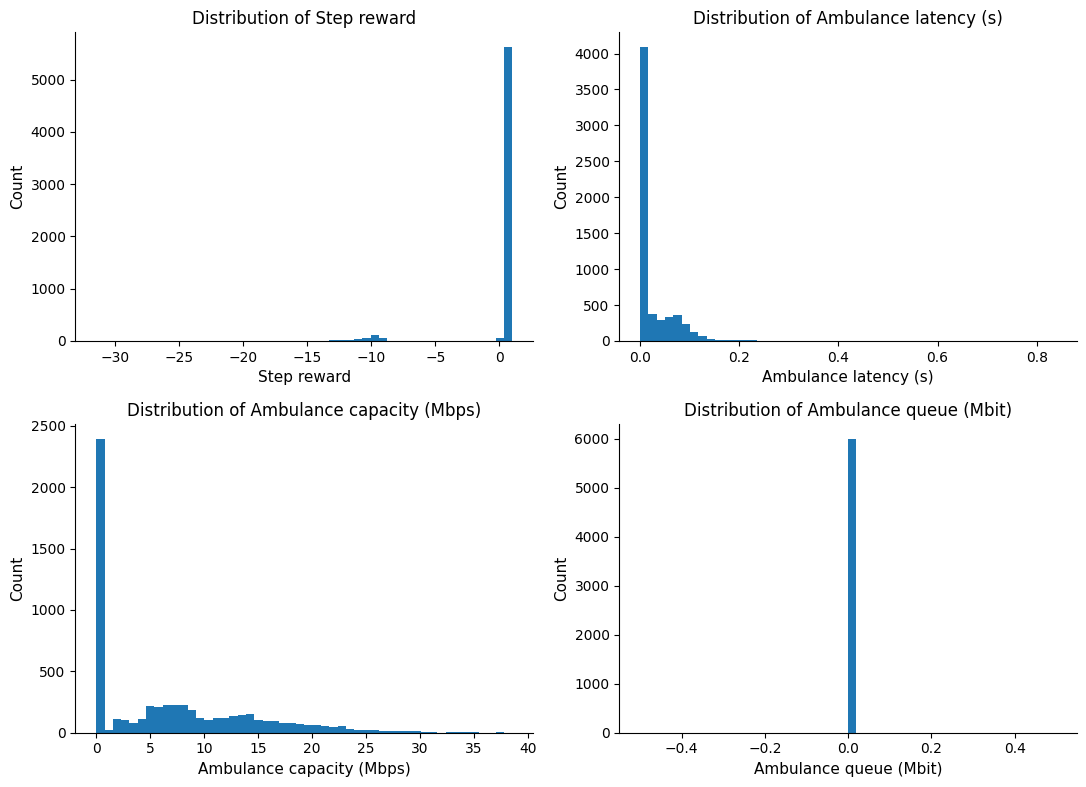

In [5]:
hist_specs = [
    ("reward_total", "Step reward"),
    ("ambulance_latency_s", "Ambulance latency (s)"),
    ("ambulance_capacity_mbps", "Ambulance capacity (Mbps)"),
    ("ambulance_queue_mbit", "Ambulance queue (Mbit)"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (column, label) in zip(axes.ravel(), hist_specs):
    ax.hist(steps_df[column].dropna(), bins=50)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {label}")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

## Scatter plots against reward

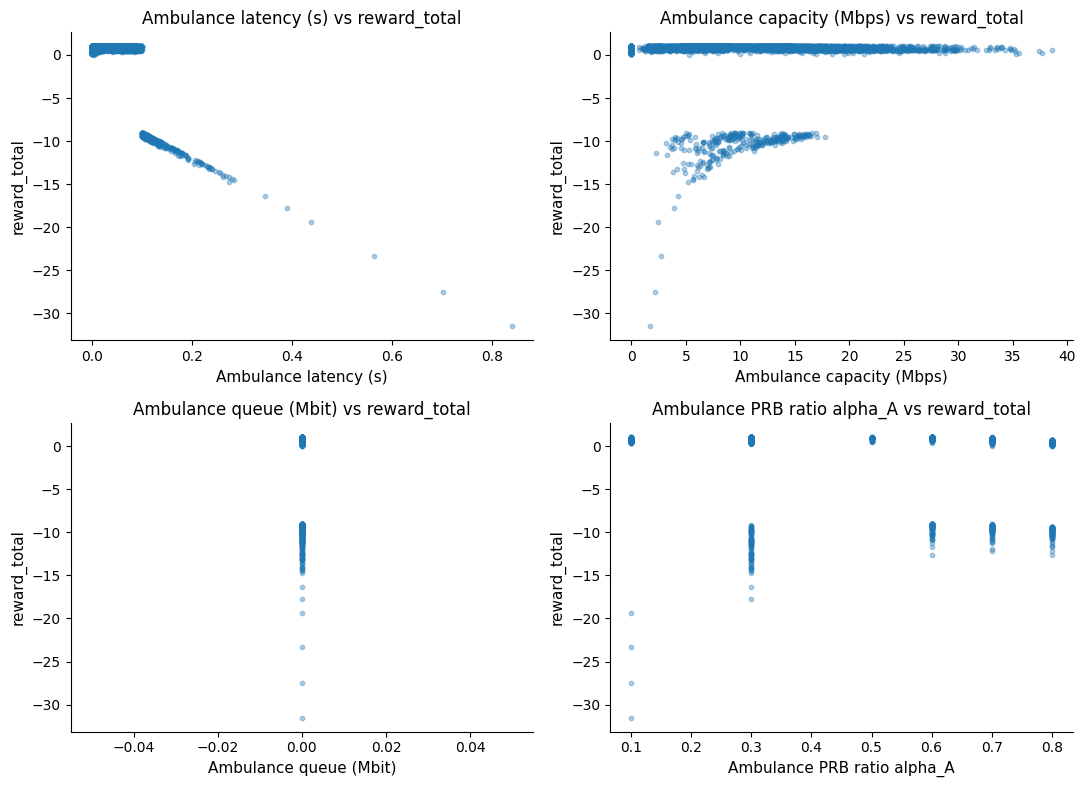

In [6]:
scatter_specs = [
    ("ambulance_latency_s", "Ambulance latency (s)"),
    ("ambulance_capacity_mbps", "Ambulance capacity (Mbps)"),
    ("ambulance_queue_mbit", "Ambulance queue (Mbit)"),
    ("alpha_A", "Ambulance PRB ratio alpha_A"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (column, label) in zip(axes.ravel(), scatter_specs):
    ax.scatter(steps_df[column], steps_df["reward_total"], s=10, alpha=0.35)
    ax.set_xlabel(label)
    ax.set_ylabel("reward_total")
    ax.set_title(f"{label} vs reward_total")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

## Group statistics by action

In [7]:
action_stats = (
    steps_df.groupby("action")
    .agg(
        mean_reward_total=("reward_total", "mean"),
        mean_ambulance_latency_s=("ambulance_latency_s", "mean"),
        mean_ambulance_sla_violation=("ambulance_sla_violation", "mean"),
        count=("reward_total", "size"),
    )
    .reset_index()
)
display(action_stats)

,action,mean_reward_total,mean_ambulance_latency_s,mean_ambulance_sla_violation,count
0,0,0.167555,0.025969,0.018868,212
1,2,0.670771,0.008187,0.021366,4025
2,4,0.891153,0.005747,0.000000,63
3,5,-0.050694,0.057984,0.095436,723
4,6,-1.026750,0.065389,0.173810,420
5,7,-1.092250,0.070143,0.154399,557


## Group statistics by ambulance emergency state

In [8]:
emergency_stats = (
    steps_df.groupby("ambulance_emergency_bool")
    .agg(
        mean_reward_total=("reward_total", "mean"),
        mean_ambulance_latency_s=("ambulance_latency_s", "mean"),
        mean_ambulance_sla_violation=("ambulance_sla_violation", "mean"),
        count=("reward_total", "size"),
    )
    .reset_index()
    .rename(columns={"ambulance_emergency_bool": "ambulance_emergency"})
)
display(emergency_stats)

,ambulance_emergency,mean_reward_total,mean_ambulance_latency_s,mean_ambulance_sla_violation,count
0,False,0.909780,0.004164,0.000000,4288
1,True,-1.276805,0.075594,0.185748,1712


## Observable factors behind catastrophic rewards

In [9]:
catastrophic_threshold = reward.quantile(0.01)
catastrophic_df = steps_df[steps_df["reward_total"] <= catastrophic_threshold].copy()
normal_df = steps_df[steps_df["reward_total"] > catastrophic_threshold].copy()

diagnostic_rows = []
for column in ["ambulance_latency_s", "ambulance_capacity_mbps", "ambulance_queue_mbit", "alpha_A"]:
    diagnostic_rows.append(
        {
            "factor": column,
            "catastrophic_mean": catastrophic_df[column].mean(),
            "non_catastrophic_mean": normal_df[column].mean(),
            "catastrophic_median": catastrophic_df[column].median(),
            "non_catastrophic_median": normal_df[column].median(),
        }
    )

diagnostic_summary = pd.DataFrame(diagnostic_rows)
display(diagnostic_summary)

emergency_catastrophic_rate = catastrophic_df["ambulance_emergency_bool"].mean()
low_alpha_emergency_rate = (
    (catastrophic_df["ambulance_emergency_bool"] & (catastrophic_df["alpha_A"] <= 0.3)).mean()
    if len(catastrophic_df) > 0 else np.nan
)

print(f"Catastrophic threshold, 1st percentile reward_total: {catastrophic_threshold}")
print(f"Catastrophic rows: {len(catastrophic_df)}")
print(f"Emergency share among catastrophic rows: {emergency_catastrophic_rate}")
print(f"Low-alpha emergency share among catastrophic rows: {low_alpha_emergency_rate}")

,factor,catastrophic_mean,non_catastrophic_mean,catastrophic_median,non_catastrophic_median
0,ambulance_latency_s,0.245872,0.022310,0.214794,0.004943
1,ambulance_capacity_mbps,6.348018,6.853815,6.651371,5.165617
2,ambulance_queue_mbit,0.000000,0.000000,0.000000,0.000000
3,alpha_A,0.363333,0.406027,0.300000,0.300000


Catastrophic threshold, 1st percentile reward_total: -11.157105218989647
Catastrophic rows: 60
Emergency share among catastrophic rows: 1.0
Low-alpha emergency share among catastrophic rows: 0.06666666666666667


## Conclusion

In [10]:
summary_min_reward = summary_df["total_reward"].min() if "total_reward" in summary_df.columns else np.nan
step_min_reward = steps_df["reward_total"].min()

dominant_factors = []
latency_ratio = catastrophic_df["ambulance_latency_s"].median() / max(normal_df["ambulance_latency_s"].median(), 1e-12)
queue_ratio = catastrophic_df["ambulance_queue_mbit"].median() / max(normal_df["ambulance_queue_mbit"].median(), 1e-12)
capacity_ratio = catastrophic_df["ambulance_capacity_mbps"].median() / max(normal_df["ambulance_capacity_mbps"].median(), 1e-12)

if latency_ratio > 2:
    dominant_factors.append("very high ambulance_latency_s")
if capacity_ratio < 0.5:
    dominant_factors.append("very low ambulance_capacity_mbps")
if queue_ratio > 2:
    dominant_factors.append("high ambulance_queue_mbit")
if low_alpha_emergency_rate > 0.5:
    dominant_factors.append("low alpha_A during emergency")
if not dominant_factors:
    dominant_factors.append("another observable factor or a combination of factors")

if np.isfinite(summary_min_reward) and summary_min_reward > catastrophic_threshold:
    evaluation_sentence = (
        "The most severe reward outliers appear mainly in the training/exploration trace rather than in deterministic evaluation, "
        "so the issue is mostly exploration-related."
    )
else:
    evaluation_sentence = (
        "Reward outliers also appear in deterministic evaluation or cannot be ruled out from the summary file, "
        "so the environment/reward design should be revised or inspected more closely."
    )

conclusion = f"""
The lowest step rewards are primarily associated with: {', '.join(dominant_factors)}.

{evaluation_sentence}

This diagnosis is based only on observable logged fields from the evaluation CSVs. It does not change the reward function, environment dynamics, training procedure, or configuration.
"""
display(Markdown(conclusion))


The lowest step rewards are primarily associated with: very high ambulance_latency_s.

Reward outliers also appear in deterministic evaluation or cannot be ruled out from the summary file, so the environment/reward design should be revised or inspected more closely.

This diagnosis is based only on observable logged fields from the evaluation CSVs. It does not change the reward function, environment dynamics, training procedure, or configuration.
